In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature



In [ ]:
df = pd.read_csv('../data/data_centers_im3_pnnl/im3_open_source_data_center_atlas_v2026.02.09.csv')
OR_df = df[df['state']=='Oregon']
non_point_df = OR_df[OR_df['type']!='point']

Text(0.5, 1.0, 'Distribution of Non-Point Data Center Square Footage in Oregon')

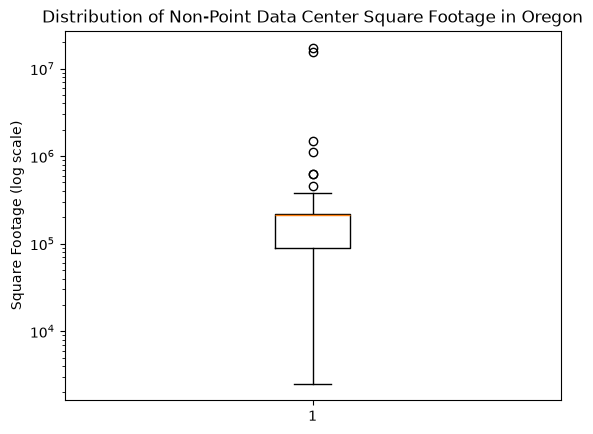

In [15]:
plt.boxplot(non_point_df['sqft'])
plt.yscale('log')
plt.ylabel('Square Footage (log scale)')
plt.title('Distribution of Non-Point Data Center Square Footage in Oregon') 

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
ax.set_extent([-124.7, -116.3, 41.9, 46.4], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
ax.add_feature(cfeature.OCEAN, facecolor="#dceeff")
ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="black", linewidth=0.7)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)

sqft = OR_df["sqft"].fillna(0)
# scale by sqrt(area) so marker area is roughly proportional to square footage
marker_size = np.clip(np.sqrt(sqft) / 15, 10, 400)

sc = ax.scatter(
    OR_df["lon"],
    OR_df["lat"],
    s=marker_size,
    c="tab:red",
    alpha=0.6,
    edgecolors="black",
    linewidths=0.3,
    transform=ccrs.PlateCarree(),
    zorder=3,
)

ax.set_title("Oregon Data Centers (marker size ~ square footage)")
gl = ax.gridlines(draw_labels=True, alpha=0.3, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False

# note: tight_layout() can raise a GEOSException on GeoAxes gridliners; use subplots_adjust instead
fig.subplots_adjust(left=0.08, right=0.95, top=0.93, bottom=0.07)
plt.show()


GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

<Figure size 900x800 with 1 Axes>